In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy import stats
from statsmodels.stats.diagnostic import breaks_cusumolsresid as cusum

In [1]:
1+1

2

### Creating dummy data

In [3]:
# Set seed for reproducibility
np.random.seed(10)

# Generate synthetic data with two breaks
X = np.linspace(0, 1, 600)
Y1 = 10 * X[:300] + np.random.normal(0, 0.1, 300)
Y2 = Y1[-1]*2-10*X[300:] + np.random.normal(0, 0.1, 300)
Y = np.concatenate([Y1, Y2])

# Stack X and Y into a DataFrame
df = pd.DataFrame({'X': X, 'Y': Y})

Plot the data

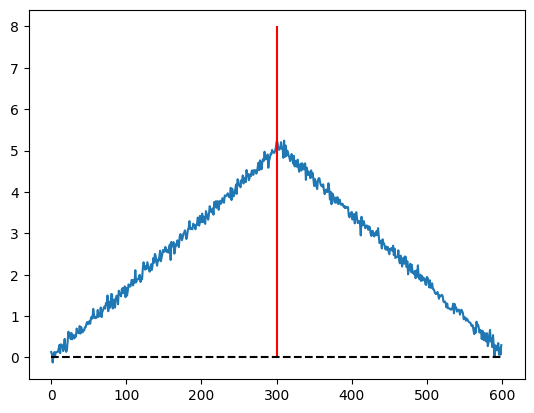

In [4]:
df['Y'].plot()
plt.vlines(300, ymin=0, ymax=8, colors='red')
plt.hlines(0, xmin=0, xmax=600, color="black", linestyles='dashed')

You can easily see three regions (growth, decrease and high vol period)

### Chow test

For this test we have to know the break

In [1]:
# Fit the model for the entire dataset
X = sm.add_constant(df['X'])
model_full = sm.OLS(df['Y'], X).fit()

# Fit the model for the first subset
X1 = sm.add_constant(df['X'][:300])
model_1 = sm.OLS(df['Y'][:300], X1).fit()

# Fit the model for the second subset
X2 = sm.add_constant(df['X'][300:])
model_2 = sm.OLS(df['Y'][300:], X2).fit()

RSS_full = sum(model_full.resid ** 2)
RSS_1 = sum(model_1.resid ** 2)
RSS_2 = sum(model_2.resid ** 2)

# Calculate the Chow test statistic
numerator = (RSS_full - (RSS_1 + RSS_2)) / 2
denominator = (RSS_1 + RSS_2 ) / 600
chow_stat = numerator / denominator

# Find the p-value
p_value = 1 - stats.f.cdf(chow_stat, 1, 597) #T-k-1

NameError: name 'sm' is not defined

In [6]:
model_full.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.016
Date:                Sat, 14 Oct 2023   Prob (F-statistic):              0.314
Time:                        16:33:39   Log-Likelihood:                -1074.7
No. Observations:                 600   AIC:                             2153.
Df Residuals:                     598   BIC:                             2162.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4684      0.119     20.827      0.000       2.236       2.701
X              0.2069      0.205      1.008      0.314      -0.196       0.610
==============================================================================
Omnibus:                      346.701   Durbin-Watson:                   0.009
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               34.867
Skew:                           0.011   Prob(JB):                     2.68e-08
Kurtosis:                       1.819   Cond. No.                         4.38
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

RSS

In [20]:
chow_stat

70242.89175236055

In [21]:
p_value

1.1102230246251565e-16

Ready to use test https://github.com/David-Woroniuk/chowtest

In [11]:
# pip install chowtest

In [12]:
from chow_test import chow_test

In [13]:
chow_test(
    y_series=df['Y'], 
    X_series=df['X'],
    last_index=299, # The final index value to be included before the data split.
    first_index=300, # The first index value to be included after the index split.
    significance=.05
)

Reject the null hypothesis of equality of regression coefficients in the two periods.
Chow Statistic: 70220.77013627511, P_value: 1.1102230246251565e-16


(70220.77013627511, 1.1102230246251565e-16)

### Test for unknown break point

### CUSUM test

The easiest non-parametric test

https://ru.wikipedia.org/wiki/CUSUM-%D1%82%D0%B5%D1%81%D1%82

https://www.statsmodels.org/dev/generated/statsmodels.stats.diagnostic.breaks_cusumolsresid.html

Probability of observing the data under the null hypothesis of no structural change, based on asymptotic distribution which is a Brownian Bridge

In [22]:
test_res = cusum(model_full.resid, 2)
print(f'P-value: {test_res[1]}')

P-value: 5.097948573951395e-25


### QLR test

This test from the lecture was shown to be superior to the CUSUM test in terms of statistical power

Specify the range for a possible break: $\underline{T}_1 \leq T_1 \leq \bar{T}_1$. Where $T_1$ is the suspected time

In [23]:
t11 = chow_test(
    y_series=df['Y'], 
    X_series=df['X'],
    last_index=280,
    first_index=281,
    significance=.05
)

t12 = chow_test(
    y_series=df['Y'], 
    X_series=df['X'],
    last_index=320,
    first_index=321,
    significance=.05
)

Reject the null hypothesis of equality of regression coefficients in the two periods.
Chow Statistic: 42376.51852055138, P_value: 1.1102230246251565e-16
Reject the null hypothesis of equality of regression coefficients in the two periods.
Chow Statistic: 57352.94842061656, P_value: 1.1102230246251565e-16


5% quantile for QLR its 8.68

In [24]:
print(f'{max(42376.5, 57352.9) = } > 8.68')

max(42376.5, 57352.9) = 57352.9 > 8.68


---
### Breaks in the variance

In [25]:
# Set seed for reproducibility
np.random.seed(10)

# Generate synthetic data with two breaks
X = np.linspace(0, 1, 600)
Y1 = 0.5 * X[:300] + np.random.normal(0, 0.1, 300)
Y2 =  0.5 * X[300:] + np.random.normal(0, 1, 300)
Y = np.concatenate([Y1, Y2])

# Stack X and Y into a DataFrame
df = pd.DataFrame({'X': X, 'Y': Y})

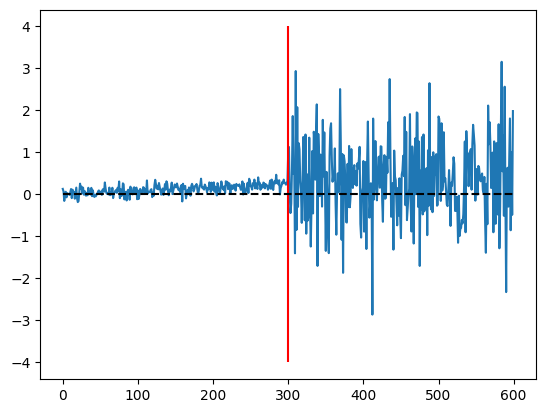

In [26]:
df['Y'].plot()
plt.vlines(300, ymin=-4, ymax=4, colors='red')
plt.hlines(0, xmin=0, xmax=600, color="black", linestyles='dashed')

### Levene test

Can be used if the break-date is known. Levene's test is equivalent to a 1-way between-groups analysis of variance (ANOVA) with the dependent variable being the absolute value of the difference between a score and the mean of the group to which the score belongs 

https://en.wikipedia.org/wiki/Levene%27s_test

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.levene.html

In [27]:
stats.levene(Y1, Y2)

LeveneResult(statistic=385.7004714210314, pvalue=1.2113013343397757e-66)

The Levene test tests the null hypothesis that all input samples are from populations with equal variances

### Regression based test from the lecture

Again, the break date should be known

In [28]:
# Fit the model for the entire dataset
X = sm.add_constant(df['X'])
model_full = sm.OLS(df['Y'], X).fit()

In [29]:
resid = model_full.resid

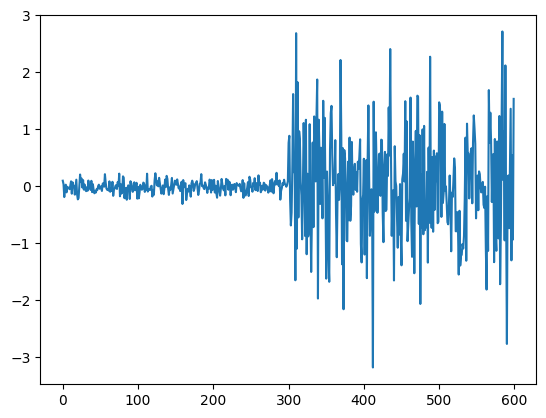

In [30]:
plt.plot(resid)

In [31]:
# Fit the model for the entire dataset
dummy = np.array([0] * 300 + [1] * 300)
X = sm.add_constant(dummy)

In [32]:
X

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 1.],
       [1., 1.],
       [1., 1.]])

In [33]:
model = sm.OLS(resid ** 2, X).fit()

In [35]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.180
Model:                            OLS   Adj. R-squared:                  0.178
Method:                 Least Squares   F-statistic:                     130.9
Date:                Sat, 14 Oct 2023   Prob (F-statistic):           1.49e-27
Time:                        16:53:30   Log-Likelihood:                -799.09
No. Observations:                 600   AIC:                             1602.
Df Residuals:                     598   BIC:                             1611.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0094      0.053      0.177      0.860      -0.095       0.113
x1             0.8578      0.075     11.443      0.000       0.711       1.005
==============================================================================
Omnibus:                      615.603   Durbin-Watson:                   1.953
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            28889.379
Skew:                           4.695   Prob(JB):                         0.00
Kurtosis:                      35.671   Cond. No.                         2.62
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

QLR test

In [36]:
t11 = chow_test(
    y_series=pd.Series(resid ** 2), 
    X_series=pd.Series(dummy),
    last_index=289,
    first_index=281,
    significance=.05
)

t12 = chow_test(
    y_series=pd.Series(resid ** 2), 
    X_series=pd.Series(dummy),
    last_index=320,
    first_index=321,
    significance=.05
)

Fail to reject the null hypothesis of equality of regression coefficients in the two periods.
Chow Statistic: -0.0014150269777453025, P_value: 1.0
Fail to reject the null hypothesis of equality of regression coefficients in the two periods.
Chow Statistic: 0.9083472265199155, P_value: 0.40374841546828244


<Axes: >

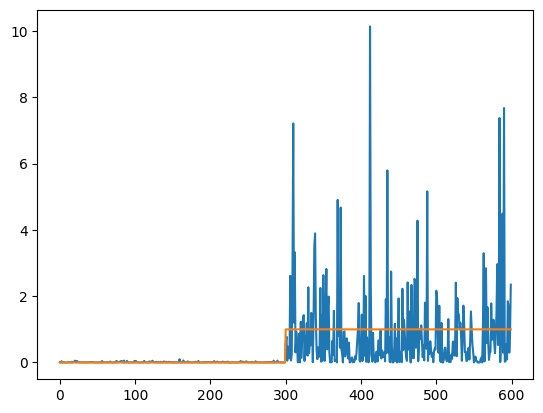

In [37]:
pd.Series(resid ** 2).plot()
pd.Series(dummy).plot()